<a href="https://colab.research.google.com/github/mukesh-code28/riscv_edge_ai/blob/main/handWrittenNumbers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import mnist

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import classification_report,accuracy_score
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
x_train=x_train.reshape(-1,28*28).astype(np.float32)
x_test=x_test.reshape(-1,28*28).astype(np.float32)

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

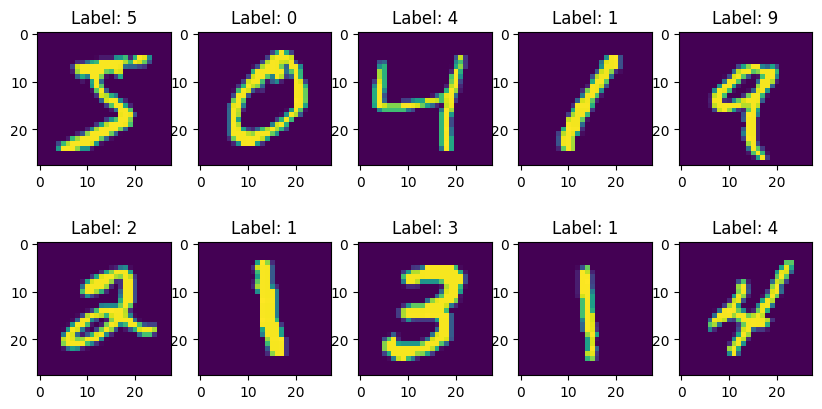

In [ ]:
fig,axes=plt.subplots(2,5,figsize=(10,5))
for i, ax in enumerate(axes.ravel()):
  ax.imshow(x_train[i].reshape(28,28))
  ax.set_title(f"Label: {y_train[i]}")
plt.show()

In [ ]:
clf=LinearSVC(dual=False,max_iter=50)

In [ ]:
clf.fit(x_train_scaled,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(dual=False, max_iter=50)

In [ ]:
y_pred=clf.predict(x_test_scaled)

In [ ]:
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.916


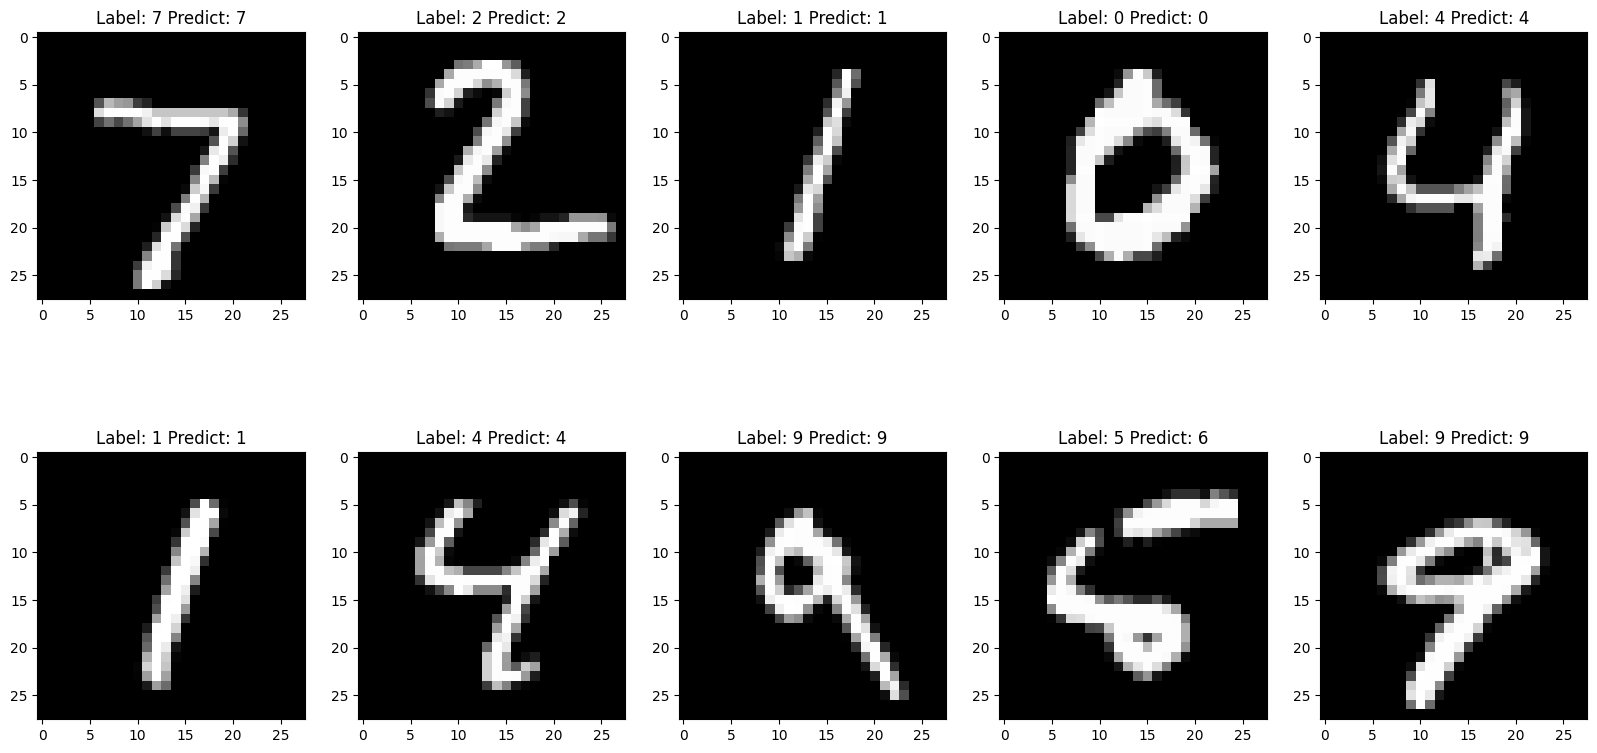

In [ ]:
fig,axes=plt.subplots(2,5,figsize=(20,10))
for i,ax in enumerate(axes.ravel()):
  ax.imshow(x_test[i].reshape(28,28),cmap='gray')
  ax.set_title(f"Label: {y_test[i]} Predict: {y_pred[i]}")
plt.show()

In [ ]:
misclassified_indices=np.where(y_test!=y_pred)[0]

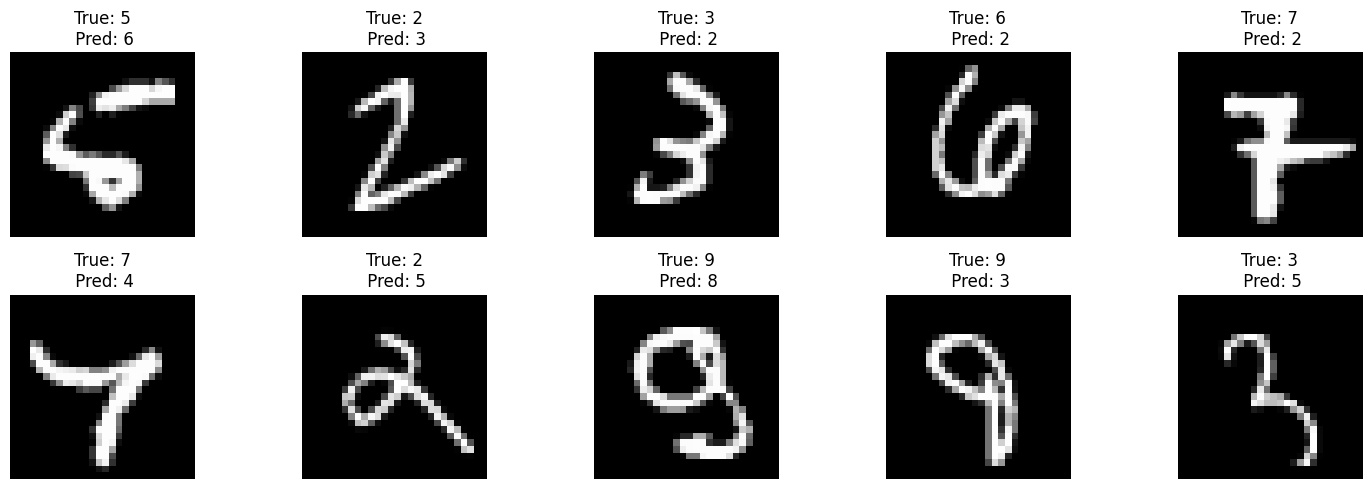

In [ ]:
plt.figure(figsize=(15,5))
for i,index in enumerate(misclassified_indices[:10]):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[index].reshape(28,28),cmap='gray')
  plt.title(f"True: {y_test[index]}\n Pred: {y_pred[index]}")
  plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
weights=clf.coef_
biases=clf.intercept_
print(weights.shape,biases)

(10, 784) [-3.06887624 -4.34677407 -1.83185358 -2.02144512 -2.76874052 -1.90933328
 -2.83053456 -3.38799132 -1.65747031 -2.6568606 ]


In [ ]:
with open("svm_model.h", "w") as f:
  f.write(f"#define NUM_CLASSES {weights.shape[0]}\n")
  f.write(f"#define NUM_FEATURES {weights.shape[1]}\n\n")
  f.write("double weights[NUM_CLASSES][NUM_FEATURES]={\n")
  for row in weights:
    f.write(" {"+", ".join(f"{v:.10f}" for v in row) + "},\n")
  f.write("};\n\n")
  f.write("double bias[NUM_CLASSES] = {"+", ".join(f"{b:.10f}" for b in biases) + "};\n")
print("Exported SVM model to svm_model.h")

Exported SVM model to svm_model.h


In [ ]:
mean = scaler.mean_
scale=scaler.scale_
with open("scaler.h","w") as f:
  f.write(f"#define NUM_FEATURES {len (mean)}\n\n")
  f.write("double mean [NUM_FEATURES] = {\n")
  f.write(" "+", ".join(f" {m:.10f}" for m in mean) + "\n};\n\n")
  f.write("double scale [NUM_FEATURES] = {\n")
  f.write(" "+ ", ".join(f" {s:.10f}" for s in scale) + "\n};\n")
print(" Exported scaler parameters to scaler.h")

 Exported scaler parameters to scaler.h


In [ ]:
NUM_IMAGES_TO_EXPORT=10

In [ ]:
assert x_test.shape[1]==784
x_sample=x_test[:NUM_IMAGES_TO_EXPORT]
y_sample=y_test[:NUM_IMAGES_TO_EXPORT]

In [ ]:
def export_test_images_to_c(images, labels, filename="test_images.h"):

    num_images, num_features = images.shape

    with open(filename, "w") as f:

        # Header guards
        f.write("#ifndef TEST_IMAGES_H\n#define TEST_IMAGES_H\n\n")

        f.write(f"#define NUM_TEST_IMAGES {num_images}\n")
        f.write(f"#define NUM_FEATURES {num_features}\n\n")

        # Write image data
        f.write("float test_images[NUM_TEST_IMAGES][NUM_FEATURES] = {\n")

        for img in images:
            f.write("    {")
            f.write(", ".join(f"{px:.6f}" for px in img))
            f.write("},\n")

        f.write("};\n\n")

        # Write labels
        f.write("int test_labels[NUM_TEST_IMAGES] = {")
        f.write(", ".join(str(label) for label in labels))
        f.write("};\n\n")

        # End header guard
        f.write("#endif // TEST_IMAGES_H\n")

    print(f"Exported {num_images} test images to {filename}")

In [ ]:
export_test_images_to_c(x_sample,y_sample,"test_images.h")

Exported 10 test images to test_images.h
